In [73]:
import ccxt
import pandas as pd
import matplotlib.pyplot as plt 

exchange = ccxt.binance()

bars = exchange.fetch_ohlcv('BTC/USDT', timeframe='1m', limit=500)

df = pd.DataFrame(bars, columns=['time','open','high','low','close','volume'])

df['time'] = pd.to_datetime(df['time'], unit='ms')
df = df.set_index('time')

In [74]:
print(df)

                         open      high       low     close    volume
time                                                                 
2026-04-15 06:58:00  73864.18  73879.70  73864.18  73879.69   2.95768
2026-04-15 06:59:00  73879.69  73904.34  73879.69  73891.62   6.82989
2026-04-15 07:00:00  73891.62  73927.70  73891.61  73915.99   7.31931
2026-04-15 07:01:00  73916.00  73916.00  73879.84  73879.84  10.47270
2026-04-15 07:02:00  73879.84  73914.79  73874.24  73914.78   5.90002
...                       ...       ...       ...       ...       ...
2026-04-15 15:13:00  74073.86  74110.00  74073.85  74091.72   3.90523
2026-04-15 15:14:00  74091.72  74299.07  74091.71  74275.11  16.46128
2026-04-15 15:15:00  74274.27  74298.02  74226.84  74272.00   6.83571
2026-04-15 15:16:00  74272.00  74277.45  74179.21  74194.25   6.56725
2026-04-15 15:17:00  74194.24  74194.25  74139.27  74150.11   6.66573

[500 rows x 5 columns]


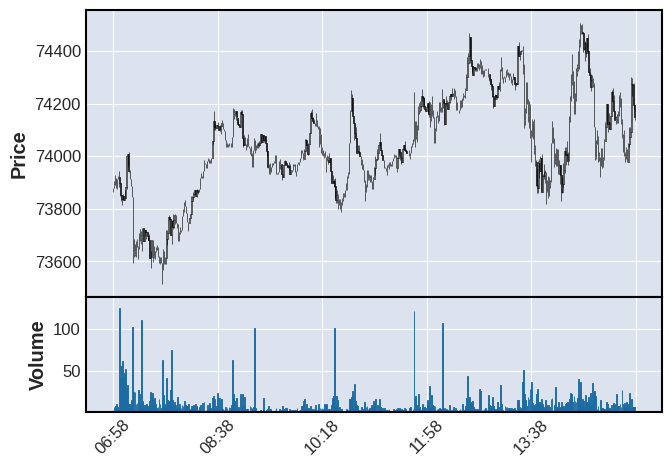

In [75]:
import mplfinance as mpf

mpf.plot(df, type='candle', volume=True)

In [76]:
print(df.columns)
print(df.head())

Index(['open', 'high', 'low', 'close', 'volume'], dtype='str')
                         open      high       low     close    volume
time                                                                 
2026-04-15 06:58:00  73864.18  73879.70  73864.18  73879.69   2.95768
2026-04-15 06:59:00  73879.69  73904.34  73879.69  73891.62   6.82989
2026-04-15 07:00:00  73891.62  73927.70  73891.61  73915.99   7.31931
2026-04-15 07:01:00  73916.00  73916.00  73879.84  73879.84  10.47270
2026-04-15 07:02:00  73879.84  73914.79  73874.24  73914.78   5.90002


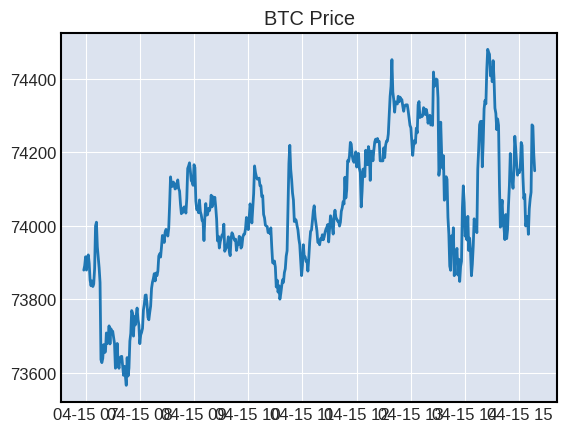

In [77]:


plt.plot(df.index, df['close'])
plt.title('BTC Price')
plt.show()

In [78]:
# add another colun for movingaverage 

df['ma_fast'] = df['close'].rolling(10).mean()
df['ma_slow'] = df['close'].rolling(30).mean()

In [79]:
df['signal'] = 0
print(df.head())

df.loc[df['ma_fast'] > df['ma_slow'], 'signal'] = 1   # BUY
df.loc[df['ma_fast'] < df['ma_slow'], 'signal'] = -1  # SELL

                         open      high       low     close    volume  \
time                                                                    
2026-04-15 06:58:00  73864.18  73879.70  73864.18  73879.69   2.95768   
2026-04-15 06:59:00  73879.69  73904.34  73879.69  73891.62   6.82989   
2026-04-15 07:00:00  73891.62  73927.70  73891.61  73915.99   7.31931   
2026-04-15 07:01:00  73916.00  73916.00  73879.84  73879.84  10.47270   
2026-04-15 07:02:00  73879.84  73914.79  73874.24  73914.78   5.90002   

                     ma_fast  ma_slow  signal  
time                                           
2026-04-15 06:58:00      NaN      NaN       0  
2026-04-15 06:59:00      NaN      NaN       0  
2026-04-15 07:00:00      NaN      NaN       0  
2026-04-15 07:01:00      NaN      NaN       0  
2026-04-15 07:02:00      NaN      NaN       0  


In [83]:
df['returns'] = df['close'].pct_change()

df['strategy_returns'] = df['signal'].shift(1) * df['returns']

print(f"{df['strategy_returns'].sum() * 100}%")

-0.3207148916832936%


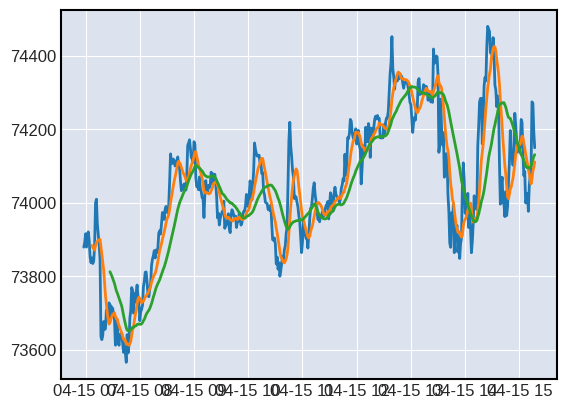

In [81]:
import matplotlib.pyplot as plt

plt.plot(df.index, df['close'])
plt.plot(df.index, df['ma_fast'])
plt.plot(df.index, df['ma_slow'])
plt.show()